In [2]:
!pip install numpy pandas matplotlib requests scipy

import pandas as pd
import numpy as np
from astropy.io import fits
import requests
import os
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import re
import scipy
import math
from scipy.optimize import curve_fit
from decimal import Decimal, getcontext
from scipy.ndimage import gaussian_filter
from datetime import datetime

#                      o  fe   na   mg   al   si   ca   ti   mn   fe
k_alphas = np.array([ 38, 53,  77,  92, 110, 128, 273, 334, 436, 474]).astype(int)

In [3]:
def smooth_moving_average(arr, window_size=3):
    """
    Smooths the array using a simple moving average.

    Parameters:
        arr (numpy.ndarray): The input array to smooth.
        window_size (int): The size of the moving average window.

    Returns:
        numpy.ndarray: The smoothed array.
    """
    return np.convolve(arr, np.ones(window_size) / window_size, mode='same')


In [4]:
def preprocess_signal_and_checks(signal):
    global moving_avg_noise_global
    """
    Preprocess the signal data to remove unnecessary parts and determine if the signal is usable.

    This function cuts the signal to a specified range, calculates statistical properties, 
    and applies threshold-based checks to classify the signal as noise or valid.

    Parameters:
        signal (numpy.ndarray): An array of length 2048 representing the counts in each channel.

    Returns:
        numpy.ndarray or None:
            - The processed signal array if the signal is valid.
            - None if the signal fails the checks.
        int:
            - Returns 1 if the signal is classified as noise.
    """
    # Define the range to analyze
    start_index = 0
    end_index = 800

    # Cut the signal to the required range
    signal_cut = signal[start_index:end_index]

    # Define threshold values
    signal_threshold = 70
    noise_threshold = 25
    noise_lower_threshold = 14
    
    
    # Check if the signal is classified as noise
    max_value_in_initial_range = np.max(signal_cut[40:400])
    
    if max_value_in_initial_range < noise_lower_threshold:
        return None
    
    if max_value_in_initial_range < noise_threshold:
        return 1

    # Check if the signal is below the usable threshold
    if max_value_in_initial_range < signal_threshold:
        return None

    # Calculate the standard deviation of the signal in the specified range
    sigma = np.std(signal_cut[35:end_index])

    # Check for validity based on a second threshold
    max_value_in_secondary_range = max(np.max(signal_cut[400:end_index]), max_value_in_initial_range)
    if max_value_in_secondary_range < 2 * sigma:
        return None
    
    moving_avg_noise_global = smooth_moving_average(moving_avg_noise_global)
    # Return the processed signal if it passes all checks
    return (signal_cut - moving_avg_noise_global)

In [5]:
def gaussian(x, amplitude, mean, sigma):

    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

In [6]:
def try_different_masks(pre_range, post_range, y, center, sigma_bounds=(0.1, 9)):
    """
    Try fitting Gaussians with different mask sizes and return possible parameters.

    Parameters:
        pre_range (int): First range for masking around the center.
        post_range (int): Second range for masking around the center.
        y (numpy.ndarray): Input data for fitting.
        center (int): Center index for fitting.
        sigma_bounds (tuple of float): Bounds for the standard deviation (sigma). Default is (0.1, 10).

    Returns:
        list of dict: List of fitted parameters for each mask size.
    """
    possible_params = []
    x = np.arange(len(y))  # Generate the x-axis values

    for itr in (pre_range, post_range):
        # Define the mask
        start = max(0, int(center - itr))
        end = min(len(y), int(center + itr + 1))

        # Masked data
        x_fit = x[start:end]
        y_fit = y[start:end]

        # Calculate initial guess
        amplitude_guess = max(y_fit)  # Ensure amplitude is positive
        mean_guess = center
        sigma_guess = (sigma_bounds[0] + sigma_bounds[1]) / 2  # Midpoint of sigma bounds

        # Ensure initial guess respects bounds
        initial_guess = [
            np.clip(amplitude_guess, 0, np.inf),
            np.clip(mean_guess, center - 10, center + 10),
            np.clip(sigma_guess, sigma_bounds[0], sigma_bounds[1])
        ]

        # Define bounds for fitting
        bounds = (
            [0, center - 10, sigma_bounds[0]],  # Lower bounds
            [np.inf, center + 10, sigma_bounds[1]]  # Upper bounds
        )

        try:
            # Fitting the Gaussian to the data
            popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=bounds)
            possible_params.append({
                'amplitude': popt[0],
                'mean': popt[1],
                'sigma': popt[2]
            })
        except ValueError as e:
            print(f"ValueError: {e}. Check `p0` or `bounds`.")
            continue
        except RuntimeError:
            # If fitting fails, skip this iteration
            continue

    return possible_params

In [7]:
def fit_multiple_gaussians(
    y,
    centers
):
    """
    Fits multiple Gaussian peaks to the y values with customizable configurations.

    Parameters:
        y (numpy.ndarray): The input y values.
        centers (list of int): Central indices of the Gaussian peaks.
        config (dict, optional): Configuration options for fitting:
            - "fit_range" (int): The number of indices around the center to include in the fit. Default is 4.
            - "initial_guess" (callable): A function to calculate initial guesses. Default uses [y[center], center, 1.0].
            - "bounds" (tuple): Bounds for the Gaussian parameters. Default is None (no bounds).

    Returns:
        list of dict: Fitted parameters for each Gaussian (amplitude, mean, sigma).
    """
    
    

    fitted_params = []
    


    for center in centers:
        
        if center == 38:                            #for Oxygen
            
            possible_params = try_different_masks(2 , 7 , y , center + 2, sigma_bounds = (0.1 , 5))
            
            
            if possible_params:
                # Calculate the area for each Gaussian
                possible_areas = [
                    p['amplitude'] * p['sigma'] * np.sqrt(2 * np.pi) for p in possible_params
                ]
                
                # Find the index of the Gaussian with the smallest area
                best_index = np.argmin(possible_areas)
                
                # Append the best Gaussian parameters
                best_param = possible_params[best_index]
                fitted_params.append(best_param)
            else:
                # If no valid Gaussians, append NaNs
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
                                    
        elif center == 53:                          # Iron L
            
            possible_params = try_different_masks(3 , 7 , y , center, sigma_bounds = (0.1 , 7))
            
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
                      
        elif center == 77:                        # for Sodium
            possible_params = try_different_masks(3 , 7 , y , center)
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
                 
            
        elif center == 92:                           # Magnesium
            
            possible_params = try_different_masks(3 , 7 , y , center)
            
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
     
            
                            
        elif center == 110:                             # Aluminium
            
            possible_params = try_different_masks(3 , 7 , y , center, sigma_bounds= (0.1, 8))
            
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
     

                   
        elif center == 128:                             # Silicon
            
            possible_params = try_different_masks(2 , 7 , y , center, sigma_bounds= (0.1,10))
            
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
        
       
        elif center == 273:                             # Calcium
           
            possible_params = try_different_masks(3 , 7 , y , center)
            
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
       
        elif center == 334:                             # Titanium
            
            possible_params = try_different_masks(3 , 7 , y , center)
            
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
      
        elif center == 436:                             # Manganese
            possible_params = try_different_masks(2 , 7 , y , center)
            
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
            
          
        elif center == 474:                             # Iron
              
            possible_params = try_different_masks(2 , 6 , y , center)
            
            if possible_params:
                    best_param = min(possible_params, key=lambda p: abs(p['mean'] - center))
                    fitted_params.append(best_param)
            else:
                fitted_params.append({'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan})
             
            
        if len(fitted_params) == 0:
                return None
    return fitted_params

In [8]:

def calculate_gaussian_areas(gaussian_params):
    """
    Calculate the areas under Gaussian curves based on their parameters.

    Parameters:
        gaussian_params (list of dict): List of Gaussian parameters where each dictionary contains:
            - 'amplitude': The peak height of the Gaussian.
            - 'mean': The center of the Gaussian (not used for area calculation).
            - 'sigma': The standard deviation of the Gaussian.

    Returns:
        list of float: Areas under the Gaussian curves.
    """
    areas = []
    for params in gaussian_params:
        amplitude = params['amplitude']
        sigma = params['sigma']

        if np.isnan(amplitude) or np.isnan(sigma):
            # Handle cases where fitting failed (NaNs in parameters)
            areas.append(np.nan)
        else:
            area = amplitude * sigma * np.sqrt(2 * np.pi)
            if area <= 0 :
                areas.append(np.nan)
            else:
                areas.append(area)
    return areas



In [9]:
def calculate_gaussian_overlaps(gaussian_params, reference_index=5):
    """
    Calculate the overlapping area of each Gaussian with the reference Gaussian.

    Parameters:
        gaussian_params (list of dict): List of Gaussian parameters where each dictionary contains:
            - 'amplitude': The peak height of the Gaussian.
            - 'mean': The center of the Gaussian.
            - 'sigma': The standard deviation of the Gaussian.
        reference_index (int): Index of the reference Gaussian to compare overlaps with (default is 4 for Gaussian 5).

    Returns:
        list of float: Overlapping areas with the reference Gaussian.
    """
    overlaps = []
    ref_gaussian = gaussian_params[reference_index]

    # Extract parameters of the reference Gaussian
    ref_amplitude = ref_gaussian['amplitude']
    ref_mean = ref_gaussian['mean']
    ref_sigma = ref_gaussian['sigma']


    # Validate the reference Gaussian
    if np.isnan(ref_amplitude) or np.isnan(ref_sigma) or ref_sigma <= 0:
        # If the reference Gaussian is invalid, return NaNs for all
        return [np.nan for _ in gaussian_params]

    for params in gaussian_params:
        amplitude = params['amplitude']
        mean = params['mean']
        sigma = params['sigma']
        
        # Validate the current Gaussian
        if np.isnan(amplitude) or np.isnan(sigma) or sigma <= 0:
            overlaps.append(np.nan)
        else:
            # Safeguard against invalid denominator
            denominator = sigma**2 + ref_sigma**2
            if denominator <= 0:
                overlaps.append(np.nan)
            else:
                # Calculate overlap
                factor = np.sqrt((2 * sigma * ref_sigma) / denominator)
                exponent = -((mean - ref_mean) ** 2) / (2 * denominator)
                overlap = amplitude * ref_amplitude * factor * np.exp(exponent)
                overlaps.append(overlap)

    return overlaps

In [10]:
moving_avg_noise_global = np.array([ 0.08206853,  0.10483031,  0.13356618,  0.14540223,  0.15190553,
        0.14576551,  0.16219475,  0.13692337,  0.14240519,  0.13009081,
        0.12639127,  0.11912618,  0.12027252,  0.12350348,  0.13473077,
        0.13845044,  0.15467508,  0.18234816,  0.20951188,  0.25208364,
        0.31270393,  0.38165426,  0.47684326,  0.60001188,  0.75957155,
        0.97422103,  1.24453434,  1.61698568,  2.11130816,  2.77158349,
        3.69820855,  4.79753056,  6.16145716,  7.79482156,  9.26570343,
       10.77875806, 11.95281274, 12.53196675, 12.86063869, 13.00150264,
       12.34770387, 11.75752504, 11.03113717,  9.97781716,  8.84068372,
        7.86695698,  6.8726727 ,  5.99550364,  5.18711929,  4.52561669,
        4.0782333 ,  3.62615678,  3.31794116,  3.01189923,  2.77550112,
        2.63436643,  2.54519492,  2.33334552,  2.24554039,  2.16805496,
        2.06546698,  2.02692866,  2.03922573,  1.94480732,  1.92187171,
        1.83987614,  1.83244523,  1.81355175,  1.82436359,  1.76945284,
        1.76518157,  1.76977042,  1.73431222,  1.75017158,  1.71771017,
        1.72614556,  1.74112747,  1.6979614 ,  1.75138415,  1.71998463,
        1.69929514,  1.75663641,  1.72319392,  1.75669543,  1.88625285,
        1.83026485,  1.87548543,  1.92147598,  1.93123162,  1.97060227,
        2.02570187,  2.130003  ,  2.10802211,  2.20101548,  2.18407077,
        2.19551308,  2.24074468,  2.37758701,  2.39747221,  2.51017659,
        2.6347842 ,  2.75110298,  2.86210004,  2.98501641,  3.0677865 ,
        3.15479904,  3.27291753,  3.31455436,  3.35043848,  3.32863459,
        3.26174202,  3.184193  ,  3.00567451,  2.89195506,  2.75439769,
        2.60310807,  2.48598565,  2.31286208,  2.16658573,  2.10849534,
        1.98443444,  1.91816486,  1.81281504,  1.7761065 ,  1.71400303,
        1.71576839,  1.64179018,  1.61347674,  1.61388868,  1.5248578 ,
        1.47400751,  1.42296198,  1.41973908,  1.36685798,  1.30052296,
        1.2569025 ,  1.18048922,  1.15563097,  1.11863744,  1.09304202,
        1.13749035,  1.04729185,  1.05535408,  1.00233425,  0.99809589,
        0.96786846,  0.96827439,  0.95238686,  0.93182964,  0.97443637,
        0.93769797,  0.91911132,  0.98734027,  0.91282175,  0.90698152,
        0.95498739,  0.94453961,  0.98538456,  0.92522947,  0.93611229,
        0.92853912,  0.99913538,  0.97118241,  0.93433969,  0.94839412,
        0.90520187,  0.91831589,  0.90463941,  0.92820684,  0.91008045,
        0.89470201,  0.88939967,  0.86800189,  0.89402803,  0.86772933,
        0.88526371,  0.84300386,  0.85668995,  0.8471684 ,  0.85274802,
        0.83429703,  0.8569495 ,  0.8272441 ,  0.83515163,  0.83597762,
        0.85945879,  0.87697272,  0.82398119,  0.82203387,  0.80347971,
        0.80314607,  0.81618777,  0.8316638 ,  0.82464954,  0.83812841,
        0.83256312,  0.82199597,  0.84097114,  0.80186471,  0.84780981,
        0.81620902,  0.80540713,  0.83941634,  0.80644066,  0.83305863,
        0.81207468,  0.81066828,  0.81541946,  0.75214594,  0.78776887,
        0.78329609,  0.78952951,  0.78145854,  0.78675642,  0.77631364,
        0.7617502 ,  0.76531457,  0.79298567,  0.77845267,  0.77643119,
        0.77966671,  0.7530551 ,  0.78686232,  0.7565043 ,  0.77512435,
        0.73764674,  0.78917585,  0.74756001,  0.74523705,  0.75289262,
        0.79357097,  0.7766713 ,  0.77804658,  0.75860375,  0.76963942,
        0.76196054,  0.75331769,  0.76565399,  0.76150163,  0.76269412,
        0.77107389,  0.76121302,  0.77808624,  0.77515045,  0.76298368,
        0.76050175,  0.73675545,  0.73056084,  0.7314576 ,  0.75039011,
        0.73469934,  0.75213242,  0.7730475 ,  0.76307584,  0.73438494,
        0.74504856,  0.73307871,  0.74353145,  0.74684853,  0.74646598,
        0.7273984 ,  0.75197812,  0.74399551,  0.75409981,  0.74551434,
        0.75127004,  0.75552684,  0.74715387,  0.73504402,  0.74831961,
        0.73583014,  0.7344333 ,  0.7278651 ,  0.74340484,  0.69696527,
        0.74895452,  0.74694903,  0.74936954,  0.73537447,  0.71493449,
        0.72303576,  0.7317203 ,  0.72954852,  0.73689994,  0.7070463 ,
        0.7053461 ,  0.71434528,  0.72603537,  0.69374027,  0.69530657,
        0.72015588,  0.6828069 ,  0.70800315,  0.70792146,  0.69862876,
        0.70890291,  0.71132038,  0.71170099,  0.69550286,  0.69096942,
        0.72653263,  0.69870528,  0.70300658,  0.71442601,  0.70959684,
        0.70075301,  0.69243311,  0.71885815,  0.69417912,  0.68811745,
        0.71952755,  0.68693595,  0.69401133,  0.70779778,  0.71672421,
        0.70351015,  0.69117489,  0.68761932,  0.68553071,  0.70636406,
        0.69419132,  0.68757481,  0.70175064,  0.70251928,  0.68944451,
        0.71630673,  0.69707672,  0.68148065,  0.69717692,  0.68720416,
        0.68497056,  0.72153841,  0.69492673,  0.73076705,  0.70482434,
        0.71064331,  0.7091755 ,  0.70020116,  0.69231854,  0.6845739 ,
        0.67629106,  0.68330992,  0.707985  ,  0.66608849,  0.67961074,
        0.65922314,  0.67646684,  0.68405862,  0.66850961,  0.67043234,
        0.66925037,  0.64704542,  0.68141171,  0.68328677,  0.66534213,
        0.68142753,  0.66721819,  0.67960096,  0.68288486,  0.67622049,
        0.66320776,  0.69534514,  0.66181787,  0.65979399,  0.6772049 ,
        0.66486787,  0.65213244,  0.67576582,  0.6610024 ,  0.66510809,
        0.67201408,  0.68157705,  0.67646179,  0.65625821,  0.66171672,
        0.66278845,  0.67467608,  0.67404935,  0.68738232,  0.66352418,
        0.66698932,  0.6733878 ,  0.67825885,  0.65799973,  0.65181466,
        0.6842903 ,  0.66408355,  0.63621163,  0.65328801,  0.65041058,
        0.65293699,  0.66017084,  0.63666077,  0.66424891,  0.65096611,
        0.64840163,  0.64988421,  0.63567735,  0.65310356,  0.64466254,
        0.66100936,  0.65927403,  0.63471165,  0.6627058 ,  0.62439889,
        0.66087782,  0.6414791 ,  0.62711368,  0.64660697,  0.65568173,
        0.6480052 ,  0.63302175,  0.65001759,  0.64375986,  0.65428377,
        0.6456636 ,  0.63440594,  0.6182818 ,  0.62613742,  0.62886092,
        0.63337734,  0.66839026,  0.63142016,  0.65902629,  0.6455216 ,
        0.65081133,  0.67141189,  0.64427854,  0.65505497,  0.65693039,
        0.63027535,  0.63808408,  0.66599101,  0.64232495,  0.65502956,
        0.68728121,  0.63693574,  0.63459924,  0.61642888,  0.61120779,
        0.63978087,  0.63749375,  0.64571561,  0.6135846 ,  0.60730094,
        0.6299068 ,  0.61622884,  0.63398731,  0.63107873,  0.63024416,
        0.61219049,  0.6627537 ,  0.61607047,  0.64240788,  0.64495787,
        0.63627849,  0.65885732,  0.64371062,  0.63819261,  0.64125528,
        0.66642375,  0.63347814,  0.645489  ,  0.65442359,  0.65527006,
        0.68079937,  0.63925681,  0.62483996,  0.64106534,  0.68716579,
        0.63562563,  0.65719994,  0.63712127,  0.66088226,  0.65448441,
        0.6647117 ,  0.62434507,  0.65753523,  0.63166618,  0.61662991,
        0.60853403,  0.62362625,  0.60009928,  0.62679611,  0.63184037,
        0.63066072,  0.62712293,  0.66104118,  0.64691882,  0.65874653,
        0.66403133,  0.65334369,  0.66112639,  0.62632559,  0.63689907,
        0.66576712,  0.64346925,  0.61205707,  0.62185908,  0.63430807,
        0.63012676,  0.63869065,  0.6153869 ,  0.62851331,  0.62842726,
        0.62023282,  0.64863672,  0.63365927,  0.63723708,  0.63965164,
        0.63228024,  0.6465695 ,  0.64295911,  0.61958639,  0.63352874,
        0.63117063,  0.64811038,  0.62265894,  0.64162655,  0.64736168,
        0.64772976,  0.62835401,  0.63333061,  0.64784291,  0.62716318,
        0.60770336,  0.63520567,  0.64857519,  0.62852507,  0.62153746,
        0.64536409,  0.62818316,  0.64385539,  0.6490275 ,  0.66957274,
        0.64633595,  0.6589809 ,  0.63837007,  0.65548648,  0.66543405,
        0.64636162,  0.66028417,  0.66840781,  0.64781756,  0.65105636,
        0.66309419,  0.69619751,  0.66877558,  0.65386465,  0.63037851,
        0.65059847,  0.64459833,  0.63917186,  0.64533424,  0.65514712,
        0.67624908,  0.66505215,  0.6645522 ,  0.66139914,  0.63572022,
        0.63774908,  0.63561986,  0.63500608,  0.6618105 ,  0.64334791,
        0.6628207 ,  0.66492651,  0.65772428,  0.64874434,  0.66178201,
        0.65526472,  0.66424214,  0.68649547,  0.67825669,  0.67283641,
        0.67402587,  0.69303084,  0.70351172,  0.7092649 ,  0.67807265,
        0.72464906,  0.72152386,  0.73458725,  0.76005628,  0.73506989,
        0.75509902,  0.74542858,  0.7921307 ,  0.77944258,  0.73053068,
        0.76905147,  0.77928332,  0.77080425,  0.74202816,  0.72921639,
        0.72942067,  0.71930158,  0.72301878,  0.66732335,  0.71256933,
        0.71699819,  0.67618711,  0.67829159,  0.67743291,  0.65737701,
        0.68926702,  0.69315547,  0.69237274,  0.68854028,  0.65694167,
        0.69050489,  0.69638387,  0.68409354,  0.64576633,  0.66659688,
        0.67404809,  0.66078017,  0.65846334,  0.66876782,  0.69519359,
        0.68948912,  0.69220176,  0.65825729,  0.68096538,  0.66907816,
        0.70916038,  0.6664452 ,  0.6583172 ,  0.66261854,  0.67423778,
        0.69321235,  0.69209631,  0.69676328,  0.69939528,  0.6717038 ,
        0.68262074,  0.6760728 ,  0.6848767 ,  0.71208106,  0.66936713,
        0.70160044,  0.70904053,  0.70723173,  0.67813452,  0.73487204,
        0.72096557,  0.7251201 ,  0.74418943,  0.71567915,  0.70870259,
        0.70634633,  0.70242404,  0.67896661,  0.67251628,  0.72224932,
        0.70077453,  0.72685912,  0.70684232,  0.73652064,  0.69383102,
        0.72056644,  0.70710262,  0.69061555,  0.69919669,  0.69393932,
        0.71925862,  0.7174388 ,  0.69435629,  0.72976739,  0.72817622,
        0.70091503,  0.75385061,  0.72625218,  0.68784405,  0.71469157,
        0.70801712,  0.69739038,  0.67815254,  0.68482377,  0.73499805,
        0.67517972,  0.68410224,  0.71007438,  0.7246844 ,  0.71689763,
        0.69626899,  0.6934814 ,  0.72255962,  0.71730415,  0.75630976,
        0.72331137,  0.70849618,  0.69469781,  0.70663227,  0.70383708,
        0.72735131,  0.71454128,  0.75268078,  0.7203582 ,  0.71393872,
        0.72431765,  0.70680882,  0.75378262,  0.76683977,  0.71662044,
        0.75355819,  0.73112542,  0.74513721,  0.74321653,  0.74478708,
        0.73947473,  0.73127932,  0.72883594,  0.73410546,  0.74807512,
        0.75851464,  0.76723198,  0.72533486,  0.73813302,  0.75760667,
        0.72901831,  0.71812867,  0.74367734,  0.74750846,  0.74664254,
        0.77067531,  0.77124626,  0.77777478,  0.75188935,  0.746534  ,
        0.75061873,  0.76200235,  0.76877301,  0.7739382 ,  0.74274121,
        0.76338496,  0.75701855,  0.76896999,  0.72561713,  0.75613739,
        0.74706412,  0.76191772,  0.7594695 ,  0.77885089,  0.71833636,
        0.76386185,  0.79779302,  0.75628641,  0.75245689,  0.74618387,
        0.7811669 ,  0.79411886,  0.76364462,  0.77949221,  0.75149596,
        0.73688936,  0.74606057,  0.76862916,  0.77122267,  0.80439456,
        0.78615473,  0.79427093,  0.76230872,  0.76674151,  0.77823409,
        0.76997891,  0.76629682,  0.75422791,  0.80145766,  0.80722621,
        0.80911611,  0.78959842,  0.78202397,  0.80462029,  0.78819228,
        0.79537314,  0.79773272,  0.8088117 ,  0.7932973 ,  0.81107626,
        0.7773116 ,  0.77472932,  0.75758289,  0.79150154,  0.76303723,
        0.75869117,  0.7681453 ,  0.7383029 ,  0.72045218,  0.74404921,
        0.71887012,  0.72494739,  0.66131663,  0.64085456,  0.59740141,
        0.54614847,  0.49835282,  0.44769053,  0.32470142,  0.2270604 ]).astype(float)

In [11]:
moving_avg_beta = 0.03

def process_fits_file(file_path, flux, avg_metadata, avg_timestamp):
    """
    Processes a single FITS file using averaged metadata and timestamp.

    Parameters:
        file_path (str): Path to the FITS file.
        flux (numpy.ndarray): Aggregated flux data.
        avg_metadata (dict): Dictionary of averaged latitude and longitude values.
        avg_timestamp (datetime): Averaged timestamp for the batch.

    Returns:
        dict: Processed results or error details.
    """
    global moving_avg_noise_global, moving_avg_beta
    try:
        # Use averaged metadata and timestamp
        V0_lat = avg_metadata["V0_lat"]
        V0_lon = avg_metadata["V0_lon"]
        V1_lat = avg_metadata["V1_lat"]
        V1_lon = avg_metadata["V1_lon"]
        V2_lat = avg_metadata["V2_lat"]
        V2_lon = avg_metadata["V2_lon"]
        V3_lat = avg_metadata["V3_lat"]
        V3_lon = avg_metadata["V3_lon"]
        date_time = avg_timestamp.strftime("%Y-%m-%dT%H:%M:%S")

        # Process the flux
        flux_processed = preprocess_signal_and_checks(flux)
        
        if flux_processed is None:
            return None
        
        if isinstance(flux_processed, int) and flux_processed == 1:
            noise_sure = flux[0:800]
            moving_avg_noise_global = (
                (1 - moving_avg_beta) * moving_avg_noise_global + (moving_avg_beta * noise_sure)
            )
            return None
        
        # Specific adjustments for oxygen channels
        if flux_processed[34] - flux_processed[36] > 4 and flux_processed[36] - flux_processed[38] > 4:
            flux_processed[34] = flux_processed[41]
            flux_processed[35] = flux_processed[40]
            flux_processed[36] = flux_processed[39]
        
        # Fit Gaussians and calculate areas and overlaps
        gaussian_params = fit_multiple_gaussians(flux_processed, k_alphas)
        areas = calculate_gaussian_areas(gaussian_params)
        overlaps = calculate_gaussian_overlaps(gaussian_params)

        # Collect results
        results = {
            "Date-Time": date_time,
            "V0_lat": V0_lat,
            "V0_lon": V0_lon,
            "V1_lat": V1_lat,
            "V1_lon": V1_lon,
            "V2_lat": V2_lat,
            "V2_lon": V2_lon,
            "V3_lat": V3_lat,
            "V3_lon": V3_lon,
        
        # Area values for each element
            "O_area": float((areas[0])),
            "Fe_area": float((areas[1] + areas[9])),
            "Na_area": float((areas[2])),
            "Mg_area": float((areas[3])),
            "Al_area": float((areas[4])),
            "Si_area": float((areas[5])),
            "Ca_area": float((areas[6])),
            "Ti_area": float((areas[7])),
            "Mn_area": float((areas[8]))
        }
        
        # Calculate uncertainty relative to Silicon
        for element, index in zip(
            ["O", "Fe", "Na", "Mg", "Al", "Ca", "Ti", "Mn"],
            [0, 1, 2, 3, 4, 6, 7, 8]
        ):
            if areas[index] <= 0 or areas[5] <= 0 or np.isnan(areas[index]) or np.isnan(areas[5]):
                results[f"{element}/Si_uncertainty"] = np.nan
            else:
                results[f"{element}/Si_uncertainty"] = float(
                    max(
                        (areas[index] / areas[5]) * (
                            (
                                ((overlaps[index] / areas[index]) ** 2) + 
                                ((overlaps[index] / areas[5]) ** 2)
                            ) ** 0.5
                        ),
                        (areas[index] / areas[5]) * (10 ** -5)
                    )
                )

        return results

    except Exception as e:  
        return {"file": file_path, "error": str(e)}

In [14]:
file_add_number = np.float64(1)
flux_global = np.zeros(2048).astype(float)
count = 0

def process_all_fits_in_folder(folder_path, num):
    """
    Processes all FITS files in the folder, aggregates flux and metadata over a batch, 
    averages timestamps, and saves results to a CSV.

    Parameters:
        folder_path (str): Path to the folder containing FITS files.
        num (int): Identifier for the output CSV.

    Outputs:
        A CSV file with the processed results.
    """
    results = []
    global moving_avg_noise_global, moving_avg_beta, file_add_number, flux_global, count

    # Initialize metadata accumulators
    latitudes = {f"V{i}_lat": 0.0 for i in range(4)}
    longitudes = {f"V{i}_lon": 0.0 for i in range(4)}
    timestamps = []  # Store datetime objects for averaging

    for root, dirs, files in os.walk(folder_path):
        # Ensure sorted traversal
        dirs.sort()
        files.sort()

        for file in files:
            if file.endswith(".fits"):
                file_path = os.path.join(root, file)

                try:
                    with fits.open(file_path) as hdul:
                        # Read flux and metadata
                        lc_data = hdul[1].data
                        flux = np.array(lc_data['COUNTS']).astype(float)
                        
                        # Read MID_UTC timestamp with fractional seconds
                        mid_utc = hdul[1].header['MID_UTC']
                        timestamps.append(datetime.strptime(mid_utc, "%Y-%m-%dT%H:%M:%S.%f"))

                        for i in range(4):
                            latitudes[f"V{i}_lat"] += hdul[1].header[f"V{i}_LAT"]
                            longitudes[f"V{i}_lon"] += hdul[1].header[f"V{i}_LON"]

                    count += 1
                    # Accumulate processed flux
                    flux_global += flux / file_add_number

                    if count == file_add_number:  # Process batch
                        # Compute average latitudes and longitudes
                        avg_metadata = {
                            key: value / file_add_number for key, value in {**latitudes, **longitudes}.items()
                        }

                        # Calculate average timestamp
                        avg_timestamp = datetime.fromtimestamp(
                            sum(t.timestamp() for t in timestamps) / len(timestamps)
                        )

                        # Reset accumulators for the next batch
                        latitudes = {key: 0.0 for key in latitudes}
                        longitudes = {key: 0.0 for key in longitudes}
                        timestamps = []  # Reset timestamp list

                        # Process batch
                        result = process_fits_file(file_path, flux_global, avg_metadata, avg_timestamp)
                        if result is not None:
                            results.append(result)
                        flux_global = np.zeros(2048).astype(float)  # Reset global flux for next batch
                        count = 0

                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")
                    continue

    # Convert results to a DataFrame
    if results:
        df = pd.DataFrame(results)
        # Generate CSV filename with the provided num
        csv_name = f"2022_individual_{num}.csv"
        df.to_csv(csv_name, index=False)
        print(f"Results saved to {csv_name}")
    else:
        print("No valid results to save.")

In [ ]:
base_dir = '/Users/suvanshsharma/Downloads/Data_22_all'

for i in range(2, 13):
    folder_name = f"cla {i}"
    folder_path = os.path.join(base_dir, folder_name)
    
    # Check if the folder exists before processing
    if os.path.isdir(folder_path):
        process_all_fits_in_folder(folder_path, i)
    else:
        print(f"Folder {folder_name} does not exist. Skipping.")

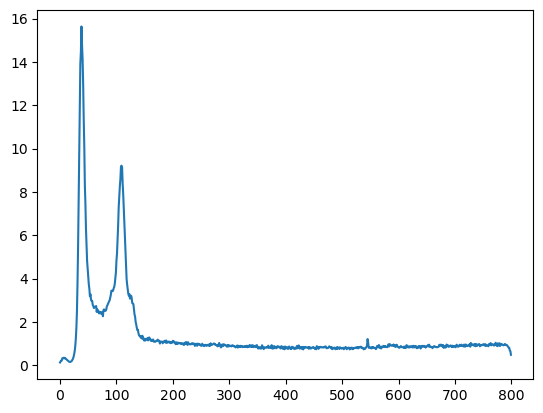

In [155]:
plt.plot((moving_avg_noise_global))
